# Sistemas de Recomendação — Trabalho Final
**Dataset:** MovieLens 1M  
**Disciplina:** Introdução à Teoria de Sistemas de Recomendação  
**Prof.:** Filipe Braida

## 1. Imports e Configurações

### 1.1: Importações

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import urllib.request
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

Imports OK


## 2. Download e Extração do MovieLens 1M

### 2.1: Download do Dataset

In [2]:
DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
DATA_DIR = 'ml-1m'
ZIP_PATH = 'ml-1m.zip'

if not os.path.exists(DATA_DIR):
    print('Baixando MovieLens 1M...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH)
    print('Download e extração concluídos.')
else:
    print('Dataset já presente em:', DATA_DIR)

Baixando MovieLens 1M...
Download e extração concluídos.


## 3. Leitura dos Arquivos

### 3.1: Carregar Avaliações (Ratings)

In [3]:
# O 1M usa separador '::' e não tem cabeçalho
ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'ratings.dat'),
    sep='::',
    names=['user_id', 'item_id', 'rating', 'timestamp'],
    engine='python',
    encoding='latin-1'
)
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

print(f'Ratings carregados: {len(ratings):,} avaliações')
ratings.head()

Ratings carregados: 1,000,209 avaliações


,user_id,item_id,rating,timestamp,datetime
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11


### 3.2: Carregar Filmes (Items)

In [4]:
# Gêneros vêm como string separada por '|' (ex: "Action|Adventure")
items = pd.read_csv(
    os.path.join(DATA_DIR, 'movies.dat'),
    sep='::',
    names=['item_id', 'title', 'genres'],
    engine='python',
    encoding='latin-1'
)
items['genre_list'] = items['genres'].str.split('|')

print(f'Filmes carregados: {len(items):,} filmes')
items.head()

Filmes carregados: 3,883 filmes


,item_id,title,genres,genre_list
0,1,Toy Story (1995),Animation|Children's|Comedy,"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama,"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


### 3.3: Carregar Usuários

In [5]:
users = pd.read_csv(
    os.path.join(DATA_DIR, 'users.dat'),
    sep='::',
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code'],
    engine='python',
    encoding='latin-1'
)

print(f'Usuários carregados: {len(users):,} usuários')
users.head()

Usuários carregados: 6,040 usuários


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## 4. Visão Geral do Dataset

### 4.1: Estatísticas Descritivas

In [ ]:
n_users   = ratings['user_id'].nunique()
n_items   = ratings['item_id'].nunique()
n_ratings = len(ratings)
matrix_size = n_users * n_items
sparsity  = 1 - n_ratings / matrix_size

print('resumo dataset 1m')
print(f'  Usuários únicos  : {n_users:>8,}')
print(f'  Filmes únicos    : {n_items:>8,}')
print(f'  Avaliações       : {n_ratings:>8,}')
print(f'  Nota mínima      : {ratings["rating"].min():>8.1f}')
print(f'  Nota máxima      : {ratings["rating"].max():>8.1f}')
print(f'  Nota média       : {ratings["rating"].mean():>8.4f}')
print(f'  Esparsidade      : {sparsity:>8.2%}')

          MOVIELENS 1M — RESUMO
  Usuários únicos  :    6,040
  Filmes únicos    :    3,706
  Avaliações       : 1,000,209
  Nota mínima      :      1.0
  Nota máxima      :      5.0
  Nota média       :   3.5816
  Esparsidade      :   95.53%


### 4.2: Gráficos de Distribuição

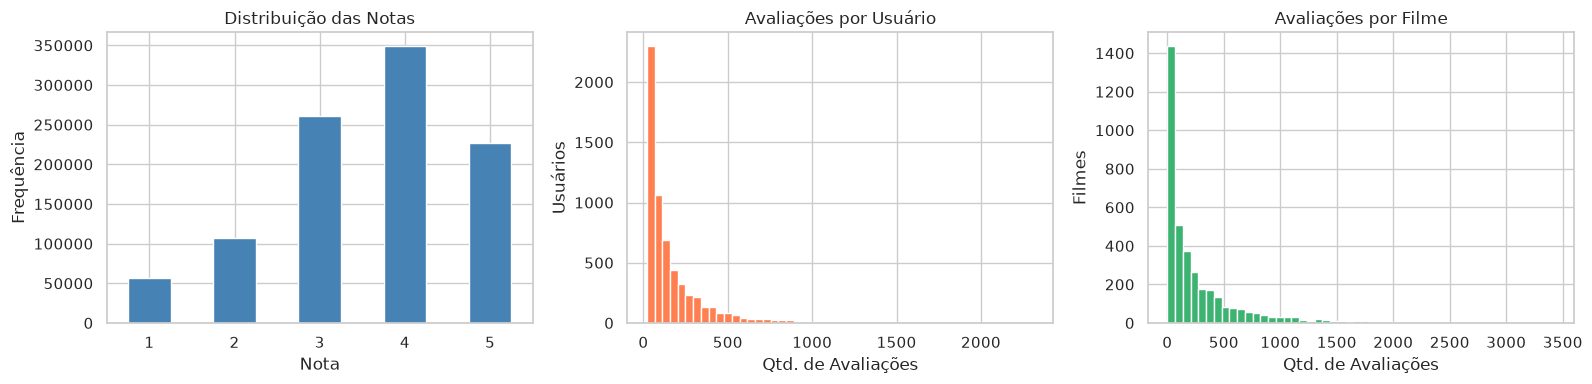

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribuição das Notas')
axes[0].set_xlabel('Nota'); axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

ratings_per_user = ratings.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Avaliações por Usuário')
axes[1].set_xlabel('Qtd. de Avaliações'); axes[1].set_ylabel('Usuários')

ratings_per_item = ratings.groupby('item_id').size()
axes[2].hist(ratings_per_item, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avaliações por Filme')
axes[2].set_xlabel('Qtd. de Avaliações'); axes[2].set_ylabel('Filmes')

plt.tight_layout()
plt.savefig('eda_overview_1m.png', bbox_inches='tight')
plt.show()

## 5. Pré-processamento e Split Treino/Validação/Teste

In [8]:
data = ratings[['user_id', 'item_id', 'rating']].copy()

train_val_data, test_data = train_test_split(data, test_size=0.20, random_state=SEED)
train_data, val_data      = train_test_split(train_val_data, test_size=0.20, random_state=SEED)

print(f'Treino    : {len(train_data):,} avaliações  ({len(train_data)/len(data):.0%})')
print(f'Validação : {len(val_data):,} avaliações  ({len(val_data)/len(data):.0%})')
print(f'Teste     : {len(test_data):,} avaliações  ({len(test_data)/len(data):.0%})')

Treino    : 640,133 avaliações  (64%)
Validação : 160,034 avaliações  (16%)
Teste     : 200,042 avaliações  (20%)


## 6. User-Based Collaborative Filtering

### 6.1: Matriz Usuário-Item

In [9]:
# ATENÇÃO: com 1M de avaliações a matriz usuário-item é muito grande.
# O User-Based CF será avaliado em uma amostra do teste para viabilizar o tempo.
user_item_matrix = train_data.pivot_table(
    index='user_id', columns='item_id', values='rating'
)

print(f'Matriz usuário-item: {user_item_matrix.shape}')
print(f'Esparsidade: {user_item_matrix.isna().sum().sum() / user_item_matrix.size:.2%}')
user_item_matrix.head(3)

Matriz usuário-item: (6040, 3650)
Esparsidade: 97.10%


item_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2: Similaridade entre Usuários

In [10]:
matrix_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(matrix_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print(f'Matriz de similaridade: {user_similarity_df.shape}')
user_similarity_df.iloc[:5, :5]

Matriz de similaridade: (6040, 6040)


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.025780,0.067568,0.000000,0.040078
2,0.025780,1.000000,0.080138,0.103454,0.076800
3,0.067568,0.080138,1.000000,0.065180,0.040307
4,0.000000,0.103454,0.065180,1.000000,0.032992
5,0.040078,0.076800,0.040307,0.032992,1.000000


### 6.3: Função de Predição

In [11]:
def predict_user_based(user_id, item_id, user_item_matrix, user_similarity_df, k=20):
    if item_id not in user_item_matrix.columns:
        return user_item_matrix.stack().mean()
    if user_id not in user_similarity_df.index:
        return user_item_matrix[item_id].mean()

    sim_scores   = user_similarity_df[user_id].drop(index=user_id)
    item_ratings = user_item_matrix[item_id].dropna()
    common_users = item_ratings.index.intersection(sim_scores.index)

    if len(common_users) == 0:
        return user_item_matrix[item_id].mean()

    sim_scores   = sim_scores[common_users]
    item_ratings = item_ratings[common_users]
    top_k        = sim_scores.abs().nlargest(k).index
    sim_scores_k = sim_scores[top_k]
    ratings_k    = item_ratings[top_k]
    denom        = sim_scores_k.abs().sum()

    if denom == 0:
        return user_item_matrix[item_id].mean()
    return (sim_scores_k * ratings_k).sum() / denom

### 6.4: Geração de Predições

In [12]:
# Amostra de 5000 para viabilizar o tempo de execução
test_sample = test_data.sample(n=5000, random_state=SEED).copy()

print('Gerando predições (pode demorar alguns minutos)...')
predictions = []
for _, row in test_sample.iterrows():
    pred = predict_user_based(
        row['user_id'], row['item_id'],
        user_item_matrix, user_similarity_df, k=30
    )
    predictions.append(pred)

test_sample['predicted'] = predictions
print('Predições concluídas.')
test_sample.head()

Gerando predições (pode demorar alguns minutos)...
Predições concluídas.


,user_id,item_id,rating,predicted
463045,2857,2268,4,3.797046
189068,1172,2710,3,3.149081
890623,5376,3681,5,4.286458
729486,4362,246,5,4.238670
376564,2197,246,4,3.827936


### 6.5: Avaliação RMSE e MAE

In [ ]:
rmse_ub = np.sqrt(mean_squared_error(test_sample['rating'], test_sample['predicted']))
mae_ub  = mean_absolute_error(test_sample['rating'], test_sample['predicted'])

print('user-based cf resultados')
print(f'  K vizinhos : 30')
print(f'  RMSE       : {rmse_ub:.4f}')
print(f'  MAE        : {mae_ub:.4f}')

   USER-BASED CF — RESULTADOS
  K vizinhos : 30
  RMSE       : 0.9624
  MAE        : 0.7686


### 6.6: Ajuste de Hiperparâmetros (K)

K=  5 | RMSE val: 1.0230 | MAE val: 0.8079
K= 10 | RMSE val: 0.9761 | MAE val: 0.7757
K= 20 | RMSE val: 0.9576 | MAE val: 0.7630
K= 30 | RMSE val: 0.9557 | MAE val: 0.7612
K= 50 | RMSE val: 0.9552 | MAE val: 0.7594
K= 75 | RMSE val: 0.9548 | MAE val: 0.7593
K=100 | RMSE val: 0.9548 | MAE val: 0.7588

Melhor K (menor RMSE na validação): 75


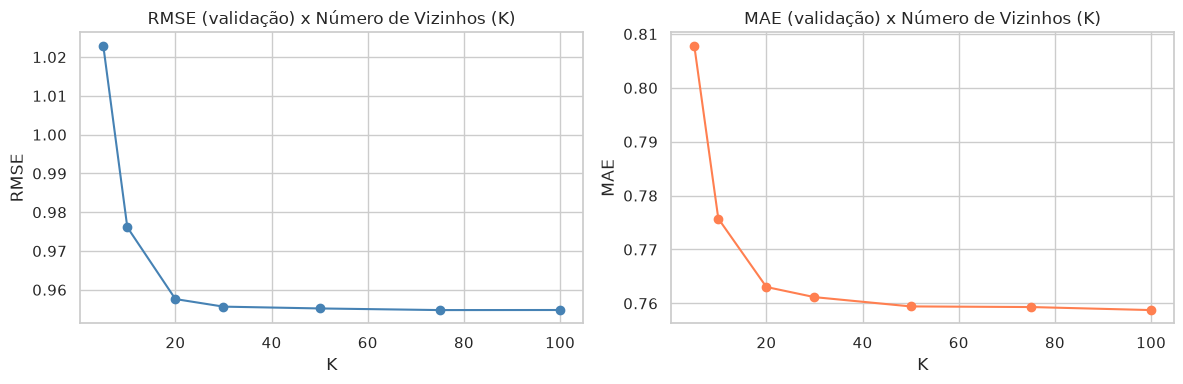

In [28]:
val_sample = val_data.sample(n=3000, random_state=SEED).copy()
k_values   = [5, 10, 20, 30, 50, 75, 100]
rmse_list, mae_list = [], []
for k in k_values:
    preds = [
        predict_user_based(row['user_id'], row['item_id'],
                           user_item_matrix, user_similarity_df, k=k)
        for _, row in val_sample.iterrows()
    ]
    rmse_list.append(np.sqrt(mean_squared_error(val_sample['rating'], preds)))
    mae_list.append(mean_absolute_error(val_sample['rating'], preds))
    print(f'K={k:>3} | RMSE val: {rmse_list[-1]:.4f} | MAE val: {mae_list[-1]:.4f}')
best_k = k_values[np.argmin(rmse_list)]
print(f'\nMelhor K (menor RMSE na validação): {best_k}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, rmse_list, marker='o', color='steelblue')
ax[0].set_title('RMSE (validação) x Número de Vizinhos (K)')
ax[0].set_xlabel('K'); ax[0].set_ylabel('RMSE')
ax[1].plot(k_values, mae_list, marker='o', color='coral')
ax[1].set_title('MAE (validação) x Número de Vizinhos (K)')
ax[1].set_xlabel('K'); ax[1].set_ylabel('MAE')
plt.tight_layout()
plt.savefig('k_vizinhos_1m.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. SVD Regularizado

### 7.1: Mapeamento de IDs para índices contíguos

In [15]:
user_ids = sorted(train_data['user_id'].unique())
item_ids = sorted(train_data['item_id'].unique())

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

print(f'Usuários no treino: {len(user2idx):,}')
print(f'Filmes no treino  : {len(item2idx):,}')

Usuários no treino: 6,040
Filmes no treino  : 3,650


### 7.2: Inicialização das matrizes de fatores latentes

In [16]:
def init_svd(n_users, n_items, n_factors, scale=0.01):
    np.random.seed(SEED)
    P  = np.random.normal(0, scale, (n_users, n_factors))   # fatores de usuários
    Q  = np.random.normal(0, scale, (n_items, n_factors))   # fatores de itens
    bu = np.zeros(n_users)                                   # bias de usuários
    bi = np.zeros(n_items)                                   # bias de itens
    return P, Q, bu, bi

### 7.3: Treinamento via SGD

In [17]:
def train_svd(train_data, user2idx, item2idx,
              n_factors=20, lr=0.005, reg=0.02, n_epochs=20, verbose=True):
    n_users = len(user2idx)
    n_items = len(item2idx)
    P, Q, bu, bi = init_svd(n_users, n_items, n_factors)
    mu      = train_data['rating'].mean()
    records = train_data[['user_id', 'item_id', 'rating']].values.copy()

    for epoch in range(1, n_epochs + 1):
        np.random.shuffle(records)
        total_loss = 0.0
        for user_id, item_id, r_ui in records:
            u = user2idx.get(user_id)
            i = item2idx.get(item_id)
            if u is None or i is None:
                continue
            pred   = mu + bu[u] + bi[i] + P[u] @ Q[i]
            err    = r_ui - pred
            total_loss += err ** 2
            bu[u]  += lr * (err - reg * bu[u])
            bi[i]  += lr * (err - reg * bi[i])
            pu_old  = P[u].copy()
            P[u]   += lr * (err * Q[i]   - reg * P[u])
            Q[i]   += lr * (err * pu_old - reg * Q[i])
        if verbose:
            print(f'Época {epoch:>2}/{n_epochs} | RMSE treino: {np.sqrt(total_loss/len(records)):.4f}')

    return P, Q, bu, bi, mu

### 7.5: Função de Predição SVD

In [19]:
def predict_svd(user_id, item_id, P, Q, bu, bi, mu, user2idx, item2idx):
    u = user2idx.get(user_id)
    i = item2idx.get(item_id)
    if u is None or i is None:
        return mu
    return float(np.clip(mu + bu[u] + bi[i] + P[u] @ Q[i], 1, 5))

### 7.4: Análise de Fatores Latentes

Fatores=  5 | RMSE val: 0.9007 | MAE val: 0.7109
Fatores= 10 | RMSE val: 0.9008 | MAE val: 0.7111
Fatores= 20 | RMSE val: 0.8938 | MAE val: 0.7052
Fatores= 50 | RMSE val: 0.8899 | MAE val: 0.7018
Fatores=100 | RMSE val: 0.8860 | MAE val: 0.6983

Melhor número de fatores (menor RMSE na validação): 100


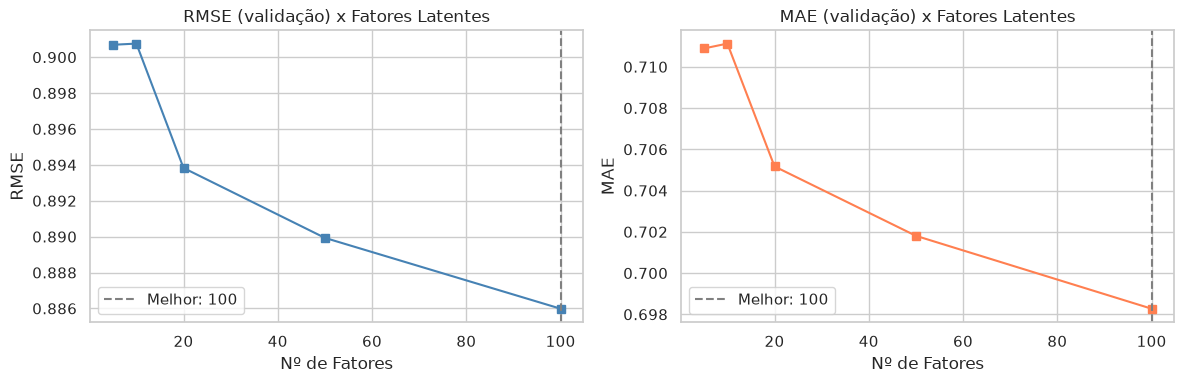

In [30]:
factors_list   = [5, 10, 20, 50, 100]
rmse_val_list, mae_val_list = [], []
for n_factors in factors_list:
    P_, Q_, bu_, bi_, mu_ = train_svd(
        train_data, user2idx, item2idx,
        n_factors=n_factors, lr=0.005, reg=0.02, n_epochs=20, verbose=False
    )
    preds_val = [
        predict_svd(row['user_id'], row['item_id'], P_, Q_, bu_, bi_, mu_, user2idx, item2idx)
        for _, row in val_data.iterrows()
    ]
    rmse_val_list.append(np.sqrt(mean_squared_error(val_data['rating'], preds_val)))
    mae_val_list.append(mean_absolute_error(val_data['rating'], preds_val))
    print(f'Fatores={n_factors:>3} | RMSE val: {rmse_val_list[-1]:.4f} | MAE val: {mae_val_list[-1]:.4f}')
best_factors = factors_list[np.argmin(rmse_val_list)]
print(f'\nMelhor número de fatores (menor RMSE na validação): {best_factors}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(factors_list, rmse_val_list, marker='s', color='steelblue')
ax[0].axvline(x=best_factors, color='gray', linestyle='--', label=f'Melhor: {best_factors}')
ax[0].set_title('RMSE (validação) x Fatores Latentes')
ax[0].set_xlabel('Nº de Fatores'); ax[0].set_ylabel('RMSE'); ax[0].legend()
ax[1].plot(factors_list, mae_val_list, marker='s', color='coral')
ax[1].axvline(x=best_factors, color='gray', linestyle='--', label=f'Melhor: {best_factors}')
ax[1].set_title('MAE (validação) x Fatores Latentes')
ax[1].set_xlabel('Nº de Fatores'); ax[1].set_ylabel('MAE'); ax[1].legend()
plt.tight_layout()
plt.savefig('rmse_mae_1m.png', bbox_inches='tight', dpi=150)
plt.show()

In [29]:
plt.savefig('rmse_mae_1m.png', bbox_inches='tight', dpi=150)

<Figure size 1000x500 with 0 Axes>

### 7.6: Treino com Melhor Fator e Avaliação Final

In [ ]:
print(f'treinando com {best_factors} fatores latentes...')
P, Q, bu, bi, mu = train_svd(
    train_data, user2idx, item2idx,
    n_factors=best_factors, lr=0.005, reg=0.02, n_epochs=20
)

svd_preds = [
    predict_svd(row['user_id'], row['item_id'], P, Q, bu, bi, mu, user2idx, item2idx)
    for _, row in test_data.iterrows()
]
test_data = test_data.copy()
test_data['svd_predicted'] = svd_preds

rmse_svd = np.sqrt(mean_squared_error(test_data['rating'], test_data['svd_predicted']))
mae_svd  = mean_absolute_error(test_data['rating'], test_data['svd_predicted'])

print('resultado final')
print(f'  Fatores latentes : {best_factors}')
print(f'  Learning rate    : 0.005')
print(f'  Regularização    : 0.02')
print(f'  Épocas           : 20')
print(f'  RMSE (teste)     : {rmse_svd:.4f}')
print(f'  MAE  (teste)     : {mae_svd:.4f}')

Retreinando com 100 fatores latentes...
Época  1/20 | RMSE treino: 0.9917
Época  2/20 | RMSE treino: 0.9311
Época  3/20 | RMSE treino: 0.9172
Época  4/20 | RMSE treino: 0.9108
Época  5/20 | RMSE treino: 0.9072
Época  6/20 | RMSE treino: 0.9050
Época  7/20 | RMSE treino: 0.9033
Época  8/20 | RMSE treino: 0.9022
Época  9/20 | RMSE treino: 0.9012
Época 10/20 | RMSE treino: 0.9003
Época 11/20 | RMSE treino: 0.8994
Época 12/20 | RMSE treino: 0.8984
Época 13/20 | RMSE treino: 0.8970
Época 14/20 | RMSE treino: 0.8951
Época 15/20 | RMSE treino: 0.8923
Época 16/20 | RMSE treino: 0.8886
Época 17/20 | RMSE treino: 0.8840
Época 18/20 | RMSE treino: 0.8788
Época 19/20 | RMSE treino: 0.8732
Época 20/20 | RMSE treino: 0.8674
   SVD REGULARIZADO — RESULTADO FINAL
  Fatores latentes : 100
  Learning rate    : 0.005
  Regularização    : 0.02
  Épocas           : 20
  RMSE (teste)     : 0.8914
  MAE  (teste)     : 0.7042


### 7.7: Comparação Final

                  Modelo     RMSE      MAE
    User-Based CF (K=75) 0.962415 0.768558
SVD Regularizado (F=100) 0.891446 0.704164


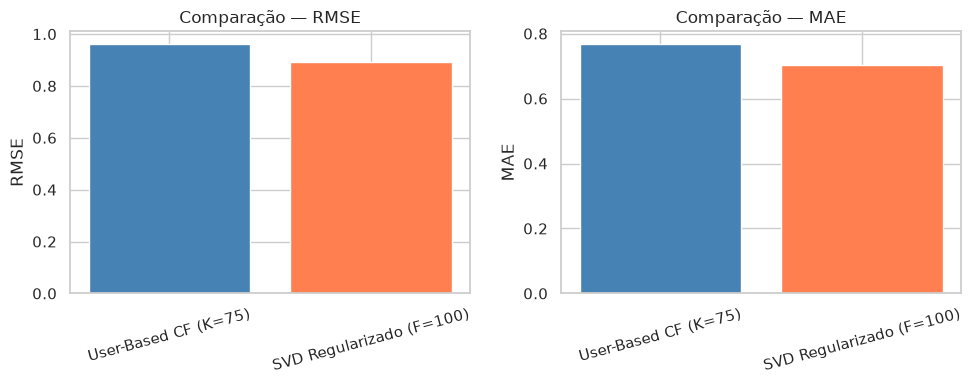

In [31]:
results = pd.DataFrame({
    'Modelo': [f'User-Based CF (K={best_k})', f'SVD Regularizado (F={best_factors})'],
    'RMSE':   [rmse_ub, rmse_svd],
    'MAE':    [mae_ub,  mae_svd]
})
print(results.to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(results['Modelo'], results['RMSE'], color=['steelblue', 'coral'], edgecolor='white')
ax[0].set_title('Comparação — RMSE'); ax[0].set_ylabel('RMSE')
ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(results['Modelo'], results['MAE'], color=['steelblue', 'coral'], edgecolor='white')
ax[1].set_title('Comparação — MAE'); ax[1].set_ylabel('MAE')
ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('comparacao_1m.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Benchmarking

### 8.1: Classificar Filmes por Popularidade

In [23]:
ratings_per_item  = train_data.groupby('item_id').size().rename('n_ratings')
popular_threshold = ratings_per_item.quantile(0.80)
rare_threshold    = ratings_per_item.quantile(0.20)
popular_items     = ratings_per_item[ratings_per_item >= popular_threshold].index
rare_items        = ratings_per_item[ratings_per_item <= rare_threshold].index

print(f'Limiar popular : >= {popular_threshold:.0f} avaliações')
print(f'Limiar raro    : <= {rare_threshold:.0f} avaliações')
print(f'Filmes populares: {len(popular_items):,}')
print(f'Filmes raros    : {len(rare_items):,}')

Limiar popular : >= 280 avaliações
Limiar raro    : <= 16 avaliações
Filmes populares: 732
Filmes raros    : 730


### 8.2: Separar Conjunto de Teste

In [24]:
# SVD — usa o teste completo
test_popular = test_data[test_data['item_id'].isin(popular_items)].copy()
test_rare    = test_data[test_data['item_id'].isin(rare_items)].copy()

# User-Based CF — usa a amostra
sample_popular = test_sample[test_sample['item_id'].isin(popular_items)].copy()
sample_rare    = test_sample[test_sample['item_id'].isin(rare_items)].copy()

print(f'Amostras de teste (SVD)  — populares: {len(test_popular):,}')
print(f'Amostras de teste (SVD)  — raros    : {len(test_rare):,}')
print(f'Amostras de teste (CF)   — populares: {len(sample_popular):,}')
print(f'Amostras de teste (CF)   — raros    : {len(sample_rare):,}')

Amostras de teste (SVD)  — populares: 129,712
Amostras de teste (SVD)  — raros    : 1,563
Amostras de teste (CF)   — populares: 3,181
Amostras de teste (CF)   — raros    : 45


### 8.3: Função Auxiliar de Métricas

In [25]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

rmse_ub_pop,  mae_ub_pop  = evaluate(sample_popular['rating'], sample_popular['predicted'])
rmse_ub_rare, mae_ub_rare = evaluate(sample_rare['rating'],    sample_rare['predicted'])

print('USER-BASED CF')
print(f'  Populares | RMSE: {rmse_ub_pop:.4f} | MAE: {mae_ub_pop:.4f}')
print(f'  Raros     | RMSE: {rmse_ub_rare:.4f} | MAE: {mae_ub_rare:.4f}')

rmse_svd_pop, mae_svd_pop   = evaluate(test_popular['rating'], test_popular['svd_predicted'])
rmse_svd_rare, mae_svd_rare = evaluate(test_rare['rating'],    test_rare['svd_predicted'])

print('SVD REGULARIZADO')
print(f'  Populares | RMSE: {rmse_svd_pop:.4f} | MAE: {mae_svd_pop:.4f}')
print(f'  Raros     | RMSE: {rmse_svd_rare:.4f} | MAE: {mae_svd_rare:.4f}')

USER-BASED CF
  Populares | RMSE: 0.9329 | MAE: 0.7424
  Raros     | RMSE: 1.1979 | MAE: 0.9651
SVD REGULARIZADO
  Populares | RMSE: 0.8760 | MAE: 0.6893
  Raros     | RMSE: 1.0757 | MAE: 0.8678


### 8.4: Tabela Comparativa Consolidada

In [26]:
bench = pd.DataFrame({
    'Modelo'  : ['User-Based CF', 'User-Based CF', 'SVD Regularizado', 'SVD Regularizado'],
    'Cenário' : ['Populares', 'Raros', 'Populares', 'Raros'],
    'RMSE'    : [rmse_ub_pop, rmse_ub_rare, rmse_svd_pop, rmse_svd_rare],
    'MAE'     : [mae_ub_pop,  mae_ub_rare,  mae_svd_pop,  mae_svd_rare],
})

print(bench.to_string(index=False))

          Modelo   Cenário     RMSE      MAE
   User-Based CF Populares 0.932851 0.742441
   User-Based CF     Raros 1.197874 0.965089
SVD Regularizado Populares 0.876011 0.689320
SVD Regularizado     Raros 1.075659 0.867788


### 8.5: Visualização do Benchmarking

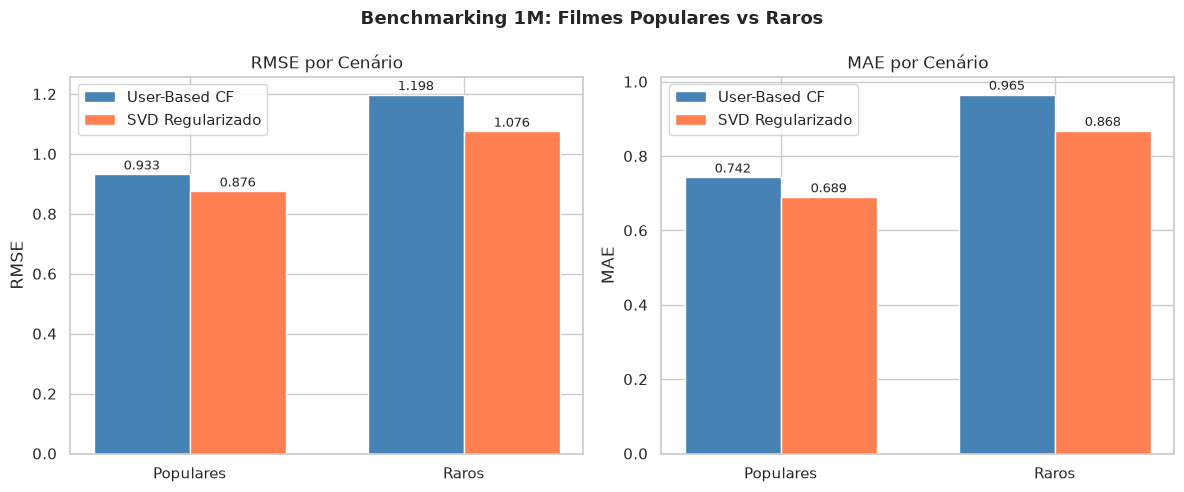

In [27]:
cenarios = ['Populares', 'Raros']
x = np.arange(len(cenarios))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    ub_vals  = bench[bench['Modelo'] == 'User-Based CF'][metric].values
    svd_vals = bench[bench['Modelo'] == 'SVD Regularizado'][metric].values

    bars1 = ax.bar(x - width/2, ub_vals,  width, label='User-Based CF',    color='steelblue', edgecolor='white')
    bars2 = ax.bar(x + width/2, svd_vals, width, label='SVD Regularizado', color='coral',     edgecolor='white')

    ax.set_title(f'{metric} por Cenário')
    ax.set_ylabel(metric); ax.set_xticks(x); ax.set_xticklabels(cenarios); ax.legend()

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Benchmarking 1M: Filmes Populares vs Raros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmarking_1m.png', bbox_inches='tight')
plt.show()